# Clase 6 — Procesamiento de Datos con R
## Actividad 3: Instancia de Evaluación — Foro Obligatorio


### Objetivo
Importar y manipular un dataset en un **data frame de R**, realizando un estudio estadístico descriptivo completo, creando nuevas variables, ordenando y filtrando los datos.

### Dataset elegido: Tips (propinas en restaurantes)
Dataset real con **244 registros** de propinas en un restaurante de EE.UU., disponible en el paquete `reshape2` de R.

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `total_bill` | Numérica continua | Importe total de la cuenta ($) |
| `tip` | Numérica continua | Propina recibida ($) |
| `sex` | Categórica nominal | Sexo del pagador (Male/Female) |
| `smoker` | Categórica nominal | Fumador (Yes/No) |
| `day` | Categórica ordinal | Día de la semana |
| `time` | Categórica nominal | Turno (Lunch/Dinner) |
| `size` | Numérica discreta | Tamaño del grupo |

---
## 1. Importar librerías y el dataset

In [ ]:
# Cargar paquetes necesarios
library(ggplot2)
library(reshape2)
data(tips)

cat('=== Primeras 6 filas (head) ===\n')
head(tips)

Warning message:
"package 'ggplot2' was built under R version 4.4.3"


Warning message:
"package 'reshape2' was built under R version 4.4.3"


=== Primeras 6 filas (head) ===


,total_bill,tip,sex,smoker,day,time,size
,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<int>
1,16.99,1.01,Female,No,Sun,Dinner,2
2,10.34,1.66,Male,No,Sun,Dinner,3
3,21.01,3.50,Male,No,Sun,Dinner,3
4,23.68,3.31,Male,No,Sun,Dinner,2
5,24.59,3.61,Female,No,Sun,Dinner,4
6,25.29,4.71,Male,No,Sun,Dinner,4


In [ ]:
cat('=== Estructura del dataset ===\n')
str(tips)
cat('\nDimensiones:', nrow(tips), 'filas x', ncol(tips), 'columnas\n')

=== Estructura del dataset ===


'data.frame':	244 obs. of  7 variables:
 $ total_bill: num  17 10.3 21 23.7 24.6 ...
 $ tip       : num  1.01 1.66 3.5 3.31 3.61 4.71 2 3.12 1.96 3.23 ...
 $ sex       : Factor w/ 2 levels "Female","Male": 1 2 2 2 1 2 2 2 2 2 ...
 $ smoker    : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 1 1 1 1 ...
 $ day       : Factor w/ 4 levels "Fri","Sat","Sun",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ time      : Factor w/ 2 levels "Dinner","Lunch": 1 1 1 1 1 1 1 1 1 1 ...
 $ size      : int  2 3 3 2 4 4 2 4 2 2 ...



Dimensiones: 244 filas x 7 columnas


---
## 2. Análisis Estadístico Descriptivo

In [ ]:
cat('=== Resumen estadístico (summary) ===\n')
summary(tips)

=== Resumen estadístico (summary) ===


   total_bill         tip             sex      smoker      day         time    
 Min.   : 3.07   Min.   : 1.000   Female: 87   No :151   Fri :19   Dinner:176  
 1st Qu.:13.35   1st Qu.: 2.000   Male  :157   Yes: 93   Sat :87   Lunch : 68  
 Median :17.80   Median : 2.900                          Sun :76               
 Mean   :19.79   Mean   : 2.998                          Thur:62               
 3rd Qu.:24.13   3rd Qu.: 3.562                                                
 Max.   :50.81   Max.   :10.000                                                
      size     
 Min.   :1.00  
 1st Qu.:2.00  
 Median :2.00  
 Mean   :2.57  
 3rd Qu.:3.00  
 Max.   :6.00  

In [ ]:
# Estadísticos individuales
cat('=== Estadísticos de tendencia central y dispersion ===\n')
for (col in c('total_bill', 'tip', 'size')) {
  cat('\nVariable:', col, '\n')
  cat('  Media:          ', round(mean(tips[[col]]), 4), '\n')
  cat('  Mediana:        ', round(median(tips[[col]]), 4), '\n')
  cat('  Desv. estandar: ', round(sd(tips[[col]]), 4), '\n')
  cat('  Varianza:       ', round(var(tips[[col]]), 4), '\n')
  cat('  Rango:          ', round(diff(range(tips[[col]])), 4), '\n')
  cat('  Min:            ', round(min(tips[[col]]), 4), '\n')
  cat('  Max:            ', round(max(tips[[col]]), 4), '\n')
}

=== Estadísticos de tendencia central y dispersion ===



Variable: total_bill 
  Media:           19.7859 
  Mediana:         17.795 
  Desv. estandar:  8.9024 
  Varianza:        79.2529 
  Rango:           47.74 
  Min:             3.07 
  Max:             50.81 

Variable: tip 
  Media:           2.9983 
  Mediana:         2.9 
  Desv. estandar:  1.3836 
  Varianza:        1.9145 
  Rango:           9 
  Min:             1 
  Max:             10 

Variable: size 
  Media:           2.5697 
  Mediana:         2 
  Desv. estandar:  0.9511 
  Varianza:        0.9046 
  Rango:           5 
  Min:             1 
  Max:             6 


In [ ]:
# Percentiles
cat('=== Percentiles de total_bill y tip ===\n')
percentiles <- c(0.10, 0.25, 0.50, 0.75, 0.90)
perc_df <- data.frame(
  Percentil  = paste0('P', percentiles * 100),
  total_bill = round(quantile(tips$total_bill, percentiles), 2),
  tip        = round(quantile(tips$tip, percentiles), 2)
)
rownames(perc_df) <- NULL
print(perc_df)

=== Percentiles de total_bill y tip ===


  Percentil total_bill  tip
1       P10      10.34 1.50
2       P25      13.35 2.00
3       P50      17.80 2.90
4       P75      24.13 3.56
5       P90      32.24 5.00


---
## 3. Tablas de Frecuencias

In [ ]:
# table() y prop.table() — frecuencias absolutas y relativas
cat('=== Tablas de frecuencia ===\n')
for (col in c('sex', 'smoker', 'day', 'time')) {
  cat('\nVariable:', toupper(col), '\n')
  abs_freq <- table(tips[[col]])
  rel_freq <- round(prop.table(abs_freq) * 100, 1)
  freq_tabla <- data.frame(
    Categoria            = names(abs_freq),
    Frecuencia_absoluta  = as.integer(abs_freq),
    Frecuencia_relativa  = paste0(as.numeric(rel_freq), '%')
  )
  print(freq_tabla, row.names = FALSE)
}

=== Tablas de frecuencia ===



Variable: SEX 
 Categoria Frecuencia_absoluta Frecuencia_relativa
    Female                  87               35.7%
      Male                 157               64.3%

Variable: SMOKER 
 Categoria Frecuencia_absoluta Frecuencia_relativa
        No                 151               61.9%
       Yes                  93               38.1%

Variable: DAY 
 Categoria Frecuencia_absoluta Frecuencia_relativa
       Fri                  19                7.8%
       Sat                  87               35.7%
       Sun                  76               31.1%
      Thur                  62               25.4%

Variable: TIME 
 Categoria Frecuencia_absoluta Frecuencia_relativa
    Dinner                 176               72.1%
     Lunch                  68               27.9%


---
## 4. Manipulación del DataFrame — Nuevas Columnas

In [ ]:
# Agregar nuevas columnas con $

# 1. Porcentaje de propina
tips$tip_pct <- round((tips$tip / tips$total_bill) * 100, 2)

# 2. Categoria de propina con ifelse
tips$tip_categoria <- ifelse(
  tips$tip_pct >= 20, 'Alta (>=20%)',
  ifelse(tips$tip_pct >= 15, 'Normal (15-20%)', 'Baja (<15%)')
)

# 3. Cuenta en pesos (1 USD = 1000 ARS)
tips$total_bill_ars <- as.integer(tips$total_bill * 1000)

cat('Dataset con nuevas columnas:\n')
head(tips, 8)
cat('\nDistribucion de categorias de propina:\n')
table(tips$tip_categoria)

Dataset con nuevas columnas:


,total_bill,tip,sex,smoker,day,time,size,tip_pct,tip_categoria,total_bill_ars
,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<int>,<dbl>,<chr>,<int>
1,16.99,1.01,Female,No,Sun,Dinner,2,5.94,Baja (<15%),16990
2,10.34,1.66,Male,No,Sun,Dinner,3,16.05,Normal (15-20%),10340
3,21.01,3.50,Male,No,Sun,Dinner,3,16.66,Normal (15-20%),21010
4,23.68,3.31,Male,No,Sun,Dinner,2,13.98,Baja (<15%),23680
5,24.59,3.61,Female,No,Sun,Dinner,4,14.68,Baja (<15%),24590
6,25.29,4.71,Male,No,Sun,Dinner,4,18.62,Normal (15-20%),25290
7,8.77,2.00,Male,No,Sun,Dinner,2,22.81,Alta (>=20%),8770
8,26.88,3.12,Male,No,Sun,Dinner,4,11.61,Baja (<15%),26880



Distribucion de categorias de propina:



   Alta (>=20%)     Baja (<15%) Normal (15-20%) 
             39             108              97 

---
## 5. Ordenamiento de Datos

In [ ]:
# Ordenar con order() en R

# Mayor a menor por total_bill
ii_desc <- order(-tips$total_bill)
cat('=== Top 5 cuentas mas altas ===\n')
print(head(tips[ii_desc, c('total_bill','tip','tip_pct','sex','day','size')], 5), row.names=FALSE)

# Menor a mayor por tip_pct
ii_asc <- order(tips$tip_pct)
cat('\n=== 5 propinas mas bajas (%) ===\n')
print(head(tips[ii_asc, c('total_bill','tip','tip_pct','sex','day')], 5), row.names=FALSE)

# Orden multiple: dia asc, total_bill desc
ii_multi <- order(tips$day, -tips$total_bill)
cat('\n=== Por dia (asc) y cuenta (desc) ===\n')
print(head(tips[ii_multi, c('day','total_bill','tip','tip_pct')], 6), row.names=FALSE)

=== Top 5 cuentas mas altas ===


 total_bill   tip tip_pct  sex day size
      50.81 10.00   19.68 Male Sat    3
      48.33  9.00   18.62 Male Sat    4
      48.27  6.73   13.94 Male Sat    4
      48.17  5.00   10.38 Male Sun    6
      45.35  3.50    7.72 Male Sun    3



=== 5 propinas mas bajas (%) ===


 total_bill  tip tip_pct    sex day
      32.83 1.17    3.56   Male Sat
      44.30 2.50    5.64 Female Sat
      26.41 1.50    5.68 Female Sat
      16.99 1.01    5.94 Female Sun
      30.46 2.00    6.57   Male Sun



=== Por dia (asc) y cuenta (desc) ===


 day total_bill  tip tip_pct
 Fri      40.17 4.73   11.77
 Fri      28.97 3.00   10.36
 Fri      27.28 4.00   14.66
 Fri      22.75 3.25   14.29
 Fri      22.49 3.50   15.56
 Fri      21.01 3.00   14.28


---
## 6. Filtrado de Datos

In [ ]:
# Filtrar con subset() en R

# Filtro 1: cuentas mayores a $30
filtro1 <- subset(tips, total_bill > 30)
cat(sprintf('=== Cuentas > $30 === (%d registros)\n', nrow(filtro1)))
print(head(filtro1[, c('total_bill','tip','tip_pct','sex','day','size')], 6), row.names=FALSE)

# Filtro 2: propina alta Y fin de semana (AND)
filtro2 <- subset(tips, tip_pct >= 20 & day %in% c('Sat','Sun'))
cat(sprintf('\n=== Propina >= 20%% en Sabado o Domingo === (%d registros)\n', nrow(filtro2)))
print(filtro2[, c('total_bill','tip','tip_pct','day','time')], row.names=FALSE)

# Filtro 3: no fumadores O cuenta > 40 (OR)
filtro3 <- subset(tips, smoker == 'No' | total_bill > 40)
cat(sprintf('\n=== No fumadores O cuenta > $40 === (%d registros)\n', nrow(filtro3)))
print(head(filtro3[, c('total_bill','tip','smoker','sex','day')], 6), row.names=FALSE)

# Filtro 4: grupos grandes en cena
filtro4 <- subset(tips, size >= 4 & time == 'Dinner')
cat(sprintf('\n=== Grupos >= 4 en cena === (%d registros)\n', nrow(filtro4)))
print(filtro4[, c('total_bill','tip','tip_pct','size','day')], row.names=FALSE)

=== Cuentas > $30 === (32 registros)


 total_bill  tip tip_pct    sex day size
      35.26 5.00   14.18 Female Sun    4
      39.42 7.58   19.23   Male Sat    4
      31.27 5.00   15.99   Male Sat    3
      30.40 5.60   18.42   Male Sun    4
      32.40 6.00   18.52   Male Sun    4
      34.81 5.20   14.94 Female Sun    4



=== Propina >= 20% en Sabado o Domingo === (25 registros)


 total_bill  tip tip_pct day   time
       8.77 2.00   22.81 Sun Dinner
      14.78 3.23   21.85 Sun Dinner
      14.83 3.02   20.36 Sun Dinner
      16.29 3.71   22.77 Sun Dinner
      16.97 3.50   20.62 Sun Dinner
      17.92 4.08   22.77 Sat Dinner
      13.94 3.06   21.95 Sun Dinner
      22.23 5.00   22.49 Sun Dinner
      10.29 2.60   25.27 Sun Dinner
      18.29 3.76   20.56 Sat Dinner
       3.07 1.00   32.57 Sat Dinner
      18.24 3.76   20.61 Sat Dinner
      14.31 4.00   27.95 Sat Dinner
      14.00 3.00   21.43 Sat Dinner
      17.31 3.50   20.22 Sun Dinner
       7.25 5.15   71.03 Sun Dinner
      16.82 4.00   23.78 Sun Dinner
       9.60 4.00   41.67 Sun Dinner
      23.33 5.65   24.22 Sun Dinner
      23.17 6.50   28.05 Sun Dinner
      20.69 5.00   24.17 Sun Dinner
      28.17 6.50   23.07 Sat Dinner
      13.28 2.72   20.48 Sat Dinner
      11.61 3.39   29.20 Sat Dinner
      29.03 5.92   20.39 Sat Dinner



=== No fumadores O cuenta > $40 === (157 registros)


 total_bill  tip smoker    sex day
      16.99 1.01     No Female Sun
      10.34 1.66     No   Male Sun
      21.01 3.50     No   Male Sun
      23.68 3.31     No   Male Sun
      24.59 3.61     No Female Sun
      25.29 4.71     No   Male Sun



=== Grupos >= 4 en cena === (37 registros)


 total_bill  tip tip_pct size day
      24.59 3.61   14.68    4 Sun
      25.29 4.71   18.62    4 Sun
      26.88 3.12   11.61    4 Sun
      35.26 5.00   14.18    4 Sun
      18.43 3.00   16.28    4 Sun
      39.42 7.58   19.23    4 Sat
      17.81 2.34   13.14    4 Sat
      18.35 2.50   13.62    4 Sat
      20.69 2.45   11.84    4 Sat
      30.40 5.60   18.42    4 Sun
      32.40 6.00   18.52    4 Sun
      34.81 5.20   14.94    4 Sun
      25.56 4.34   16.98    4 Sun
      38.01 3.00    7.89    4 Sat
      48.27 6.73   13.94    4 Sat
      18.29 3.76   20.56    4 Sat
      40.17 4.73   11.77    4 Fri
      29.93 5.07   16.94    4 Sun
      24.55 2.00    8.15    4 Sun
      19.77 2.00   10.12    4 Sun
      29.85 5.14   17.22    5 Sun
      48.17 5.00   10.38    6 Sun
      25.00 3.75   15.00    4 Sun
      16.49 2.00   12.13    4 Sun
      21.50 3.50   16.28    4 Sun
      31.71 4.50   14.19    4 Sun
      34.65 3.68   10.62    4 Sun
      23.17 6.50   28.05    4 Sun
      20.69 5.

---
## 7. Estadísticos por Grupos

In [ ]:
# aggregate() — estadísticos por grupo
cat('=== Media por Dia ===\n')
medias_dia <- aggregate(cbind(total_bill, tip, tip_pct) ~ day, data=tips, FUN=mean)
medias_dia[, 2:4] <- round(medias_dia[, 2:4], 2)
print(medias_dia, row.names=FALSE)

cat('\n=== Media de tip_pct por Sexo y Turno ===\n')
medias_st <- aggregate(tip_pct ~ sex + time, data=tips, FUN=mean)
medias_st$tip_pct <- round(medias_st$tip_pct, 2)
print(medias_st, row.names=FALSE)

cat('\n=== Tabla cruzada: Fumador vs Categoria ===\n')
print(table(tips$smoker, tips$tip_categoria))

=== Media por Dia ===


  day total_bill  tip tip_pct
  Fri      17.15 2.73   16.99
  Sat      20.44 2.99   15.31
  Sun      21.41 3.26   16.69
 Thur      17.68 2.77   16.13



=== Media de tip_pct por Sexo y Turno ===


    sex   time tip_pct
 Female Dinner   16.93
   Male Dinner   15.54
 Female  Lunch   16.23
   Male  Lunch   16.61



=== Tabla cruzada: Fumador vs Categoria ===


     
      Alta (>=20%) Baja (<15%) Normal (15-20%)
  No            23          67              61
  Yes           16          41              36


---
## 8. Visualizaciones con ggplot2

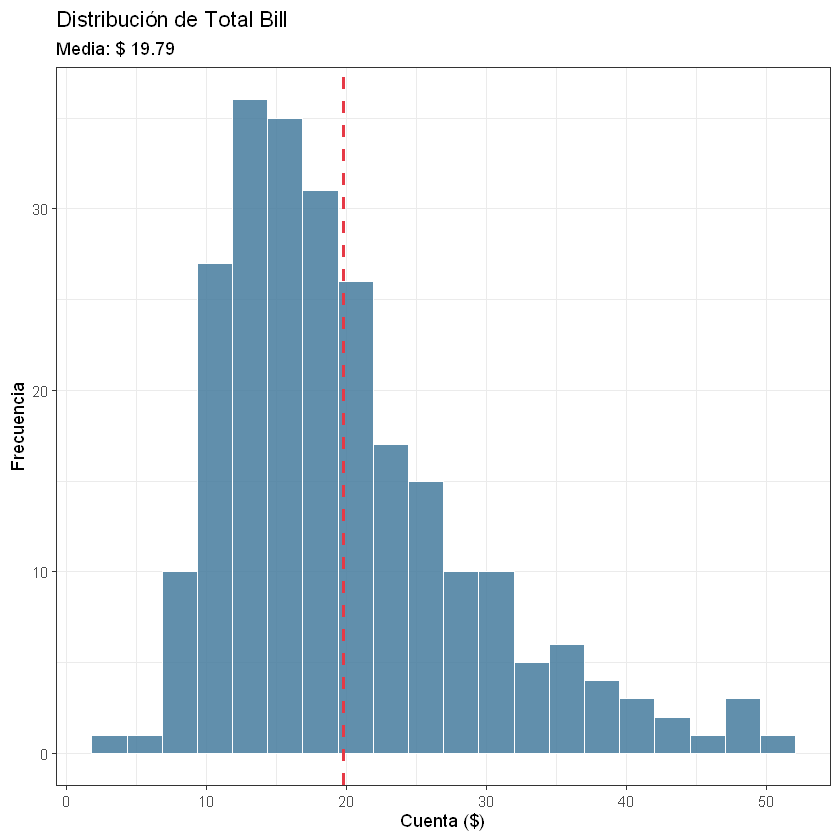

In [ ]:
# Visualización 1: Histograma de total_bill
p1 <- ggplot(tips, aes(x=total_bill)) +
  geom_histogram(bins=20, fill='#457b9d', color='white', alpha=0.85) +
  geom_vline(xintercept=mean(tips$total_bill), color='#e63946',
             linetype='dashed', linewidth=1) +
  labs(title='Distribución de Total Bill',
       subtitle=paste('Media: $', round(mean(tips$total_bill),2)),
       x='Cuenta ($)', y='Frecuencia') +
  theme_bw()
print(p1)

`geom_smooth()` using formula = 'y ~ x'


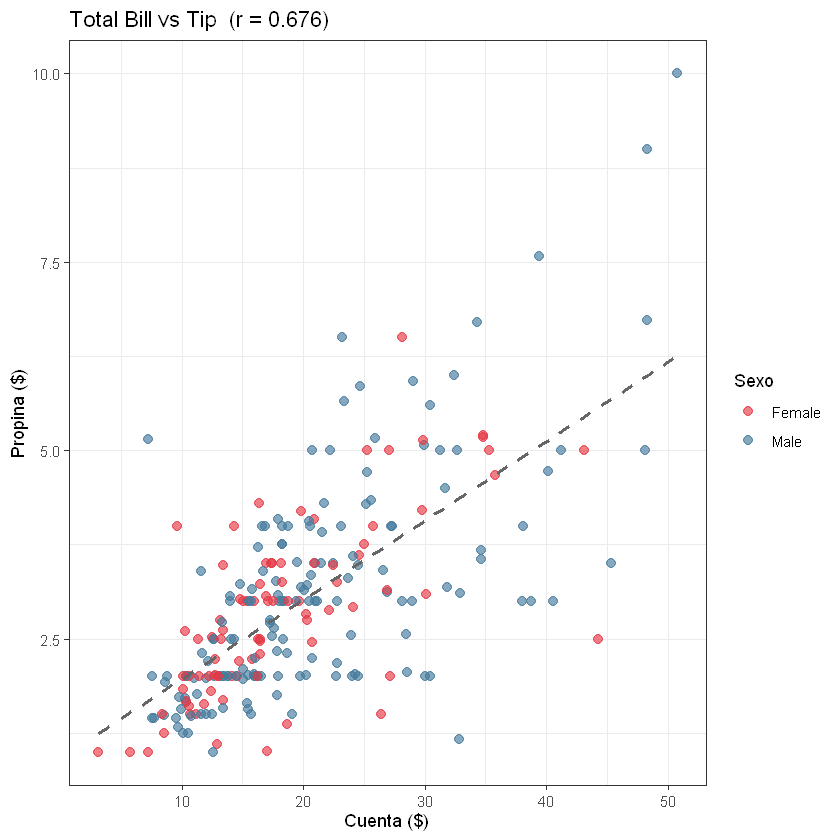

In [ ]:
# Visualización 2: Scatter total_bill vs tip por sexo + línea de tendencia
corel <- round(cor(tips$total_bill, tips$tip), 3)
p2 <- ggplot(tips, aes(x=total_bill, y=tip, color=sex)) +
  geom_point(alpha=0.65, size=2.5) +
  geom_smooth(method='lm', se=FALSE, color='gray40', linetype='dashed') +
  scale_color_manual(values=c('Female'='#e63946', 'Male'='#457b9d')) +
  labs(title=paste0('Total Bill vs Tip  (r = ', corel, ')'),
       x='Cuenta ($)', y='Propina ($)', color='Sexo') +
  theme_bw()
print(p2)

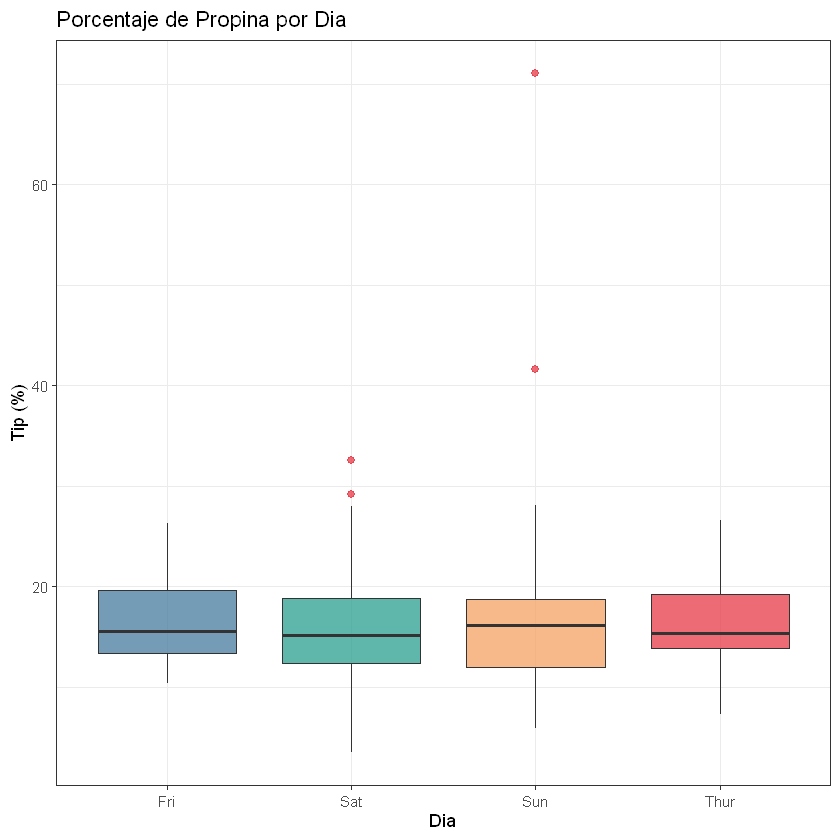

In [ ]:
# Visualización 3: Boxplot de tip_pct por dia
p3 <- ggplot(tips, aes(x=day, y=tip_pct, fill=day)) +
  geom_boxplot(alpha=0.75, outlier.color='#e63946', outlier.size=2) +
  scale_fill_manual(values=c('Thur'='#e63946','Fri'='#457b9d','Sat'='#2a9d8f','Sun'='#f4a261')) +
  labs(title='Porcentaje de Propina por Dia', x='Dia', y='Tip (%)', fill='Dia') +
  theme_bw() + theme(legend.position='none')
print(p3)

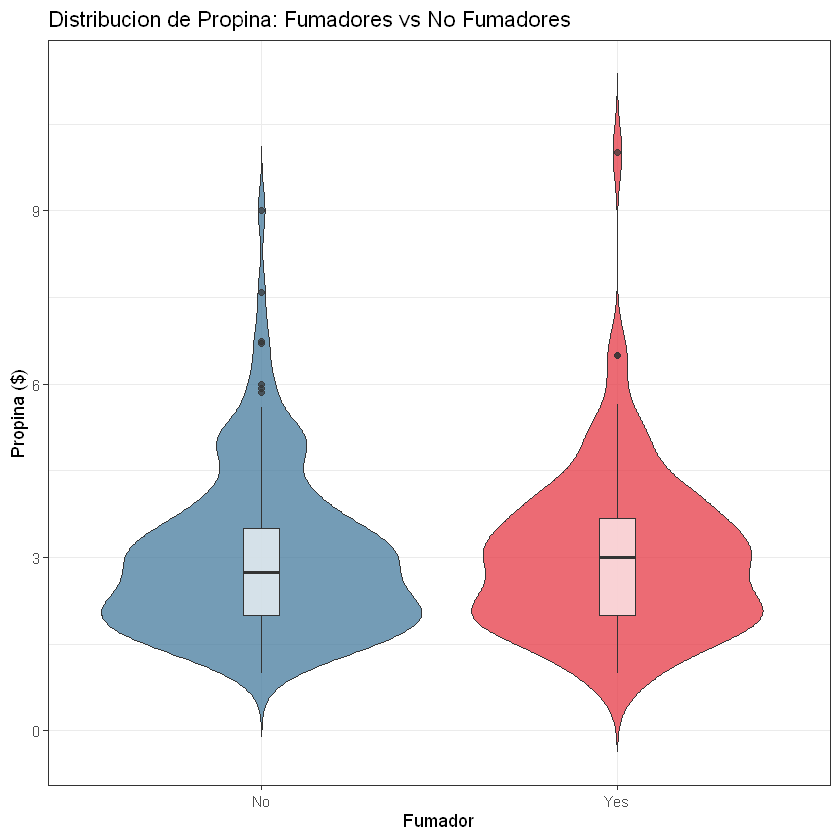

In [ ]:
# Visualización 4: Violin plot fumadores vs no fumadores
p4 <- ggplot(tips, aes(x=smoker, y=tip, fill=smoker)) +
  geom_violin(alpha=0.75, trim=FALSE) +
  geom_boxplot(width=0.1, fill='white', alpha=0.7) +
  scale_fill_manual(values=c('Yes'='#e63946', 'No'='#457b9d')) +
  labs(title='Distribucion de Propina: Fumadores vs No Fumadores',
       x='Fumador', y='Propina ($)') +
  theme_bw() + theme(legend.position='none')
print(p4)

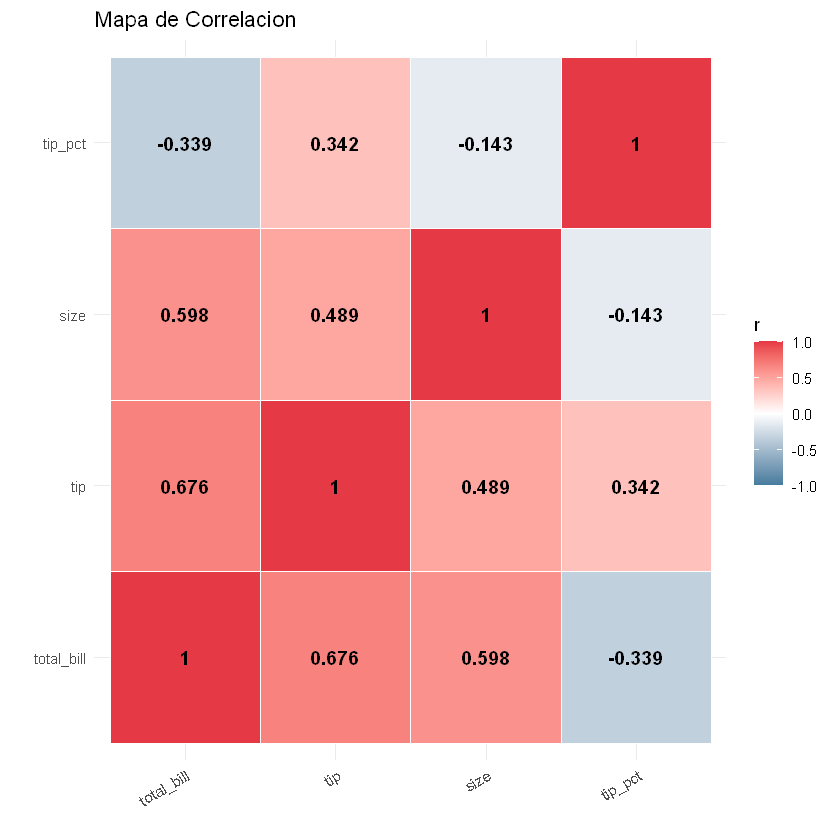

In [ ]:
# Visualización 5: Heatmap de correlaciones
num_vars  <- tips[, c('total_bill','tip','size','tip_pct')]
corr_mat  <- round(cor(num_vars), 3)
corr_melt <- melt(corr_mat)

p5 <- ggplot(corr_melt, aes(x=Var1, y=Var2, fill=value)) +
  geom_tile(color='white') +
  geom_text(aes(label=value), size=4, fontface='bold') +
  scale_fill_gradient2(low='#457b9d', mid='white', high='#e63946',
                       midpoint=0, limits=c(-1,1), name='r') +
  labs(title='Mapa de Correlacion', x='', y='') +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=30, hjust=1))
print(p5)

---
## 9. Conclusiones

### Hallazgos estadísticos principales

| Estadístico | total_bill | tip | tip_pct |
|-------------|-----------|-----|--------|
| Media | $19.79 | $3.00 | ~16.1% |
| Mediana | $17.80 | $2.90 | ~15.5% |
| Desv. estándar | $8.90 | $1.38 | ~5.6% |
| Mínimo | $3.07 | $1.00 | ~3.6% |
| Máximo | $50.81 | $10.00 | ~71% |

### Principales hallazgos

1. **Correlación fuerte entre cuenta y propina** (r ≈ 0.68): a mayor cuenta, mayor propina en valor absoluto.
2. **El porcentaje promedio de propina es ~16%**, con alta variabilidad — hay clientes que propinaron más del 70%.
3. **Los domingos** tienen las cuentas más altas en promedio.
4. **Fumadores vs no fumadores**: distribuciones de propina muy similares (violin plot lo confirma).
5. **tip_pct tiene baja correlación con size** — grupos grandes no dejan más propina en porcentaje.

